## Loss Function
Aims:
- Determine if MSE (and other) loss functions are biased towards small IM values due to log-space
- Find a loss function that isn't as prone to outliers as MSE

In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pygmt

# Grow the GPU memory usage as needed
gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices("GPU")
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

import nn_gmm

2022-03-29 09:36:08.931011: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2022-03-29 09:36:10.070097: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2022-03-29 09:36:10.070150: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2022-03-29 09:36:10.127138: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-29 09:36:10.127433: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:08:00.0 name: NVIDIA GeForce RTX 2060 computeCapability: 7.5
coreClock: 1.755GHz coreCount: 30 deviceMemorySize: 5.79GiB deviceMemoryBandwidth: 312.97GiB/s
2022-03-29 09:36:10.127448: I tensorflow/stream_executor/platform/de

1 Physical GPUs, 1 Logical GPUs


In [2]:
model_dir = Path("/home/claudy/dev/work/data/nn_gmm/results/keep_runs/current/0301_145629_base-grid_fault-weights_XYZ_loc")

columns = ["site", "lat", "lon", "pSA_3.0", "pSA_3.0_est", "event", "vs30"]
data_df = nn_gmm.ResultDB.get_data_static(model_dir / "train_predictions.hdf5", columns=columns)
data_df["res"] = data_df["pSA_3.0"] - data_df["pSA_3.0_est"]
data_df["squared_res"] = data_df["res"].values**2
data_df["realisation"] = np.stack(np.char.rsplit(data_df.index.values.astype(str), "_", maxsplit=1))[:, 0]

In [3]:
# Get the top 1% of outliers
data_df.sort_values("squared_res", ascending=False, inplace=True)
mask = data_df.squared_res > np.quantile(data_df.squared_res, 0.999)

In [18]:
def mse(y: np.ndarray, y_pred: np.ndarray):
    return (y - y_pred)**2

# def mse_log(y: np.ndarray, y_pred: np.ndarray):
#     return (np.log(y + 1) - np.log(y_pred + 1))**2

def huber_loss(y: np.ndarray, y_pred: np.ndarray, d: float):
    error = y - y_pred
    return np.where(np.abs(error) < d, 0.5 * error**2, d * np.abs(error) - 0.5 * d**2)

In [5]:
np.exp(-8)

0.00033546262790251185

In [34]:
# Look at how loss changes for a constant (non-log) residual

error = 0.001
# im_values = np.geomspace(np.exp(data_df["pSA_3.0"].min()), np.exp(data_df["pSA_3.0"].values.max()), 1000)
im_values = np.geomspace(1e-4, np.exp(data_df["pSA_3.0"].values.max()), 1000)
im_values_pred = im_values + error
mse_values = mse(np.log(im_values), np.log(im_values_pred))
huber_values = huber_loss(np.log(im_values), np.log(im_values_pred), 0.2)

logbins = np.geomspace(np.exp(data_df["pSA_3.0"].values.min()), np.exp(data_df["pSA_3.0"].values.max()), 50)
counts, bins = np.histogram(np.exp(data_df["pSA_3.0"].values), bins=logbins)
counts = (counts / counts.max()) * mse_values.max()

outlier_counts, outlier_bins = np.histogram(np.exp(data_df.loc[mask, "pSA_3.0"].values), bins=logbins)
outlier_counts = (outlier_counts / outlier_counts.max()) * mse_values.max()

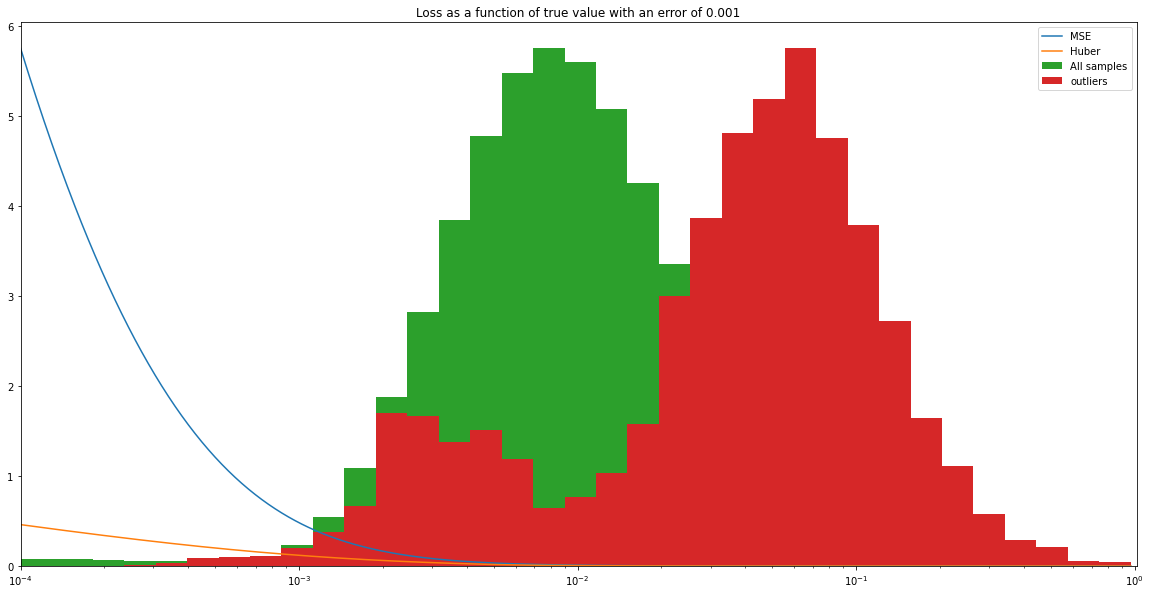

In [39]:
fig = plt.figure(figsize=(20, 10))
plt.plot(im_values, mse_values, label="MSE");
plt.plot(im_values, huber_values, label="Huber");

plt.hist(bins[:-1], bins, weights=counts, label="All samples");
plt.hist(outlier_bins[:-1], outlier_bins, weights=outlier_counts, label="outliers");

plt.title(f"Loss as a function of true value with an error of {error}")

plt.xlim(1e-4, None)
# plt.ylim(0.0, 1.0)

plt.semilogx();
plt.legend();

## Huber Loss
Look at Huber loss for loss function, see what an appropriate threshold would be

(0.0, 2.0)

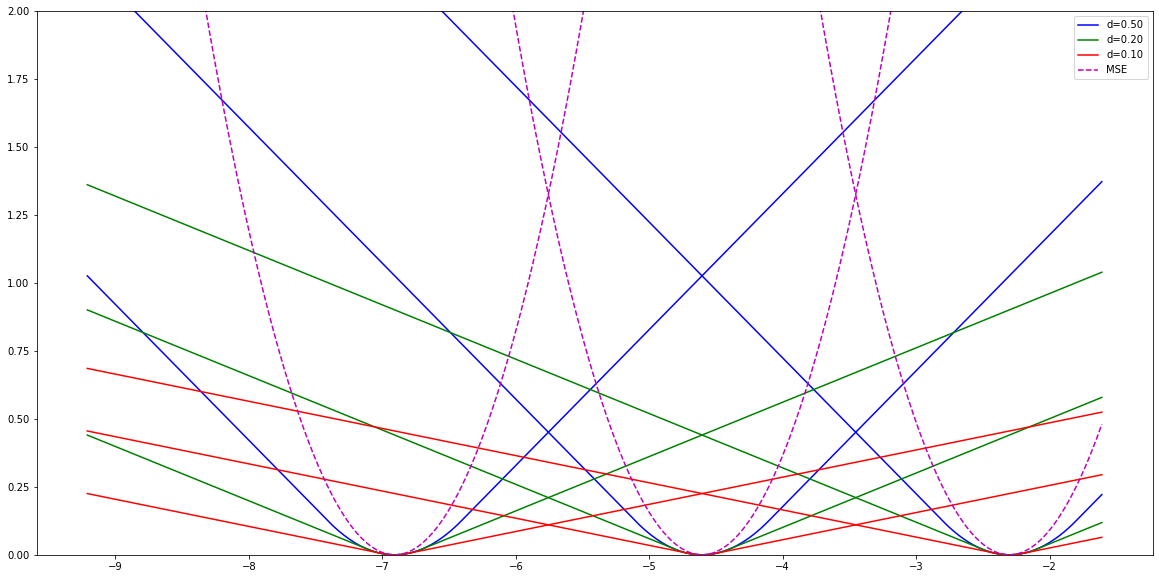

In [23]:
y_true = np.log(np.asarray([0.1, 0.01, 0.001]))
# y_pred = np.linspace(0.0001, 0.2, 1000)
y_pred = np.log(np.geomspace(0.0001, 0.2, 1000))
# d_values = np.log([0.1, 0.01, 0.001])
d_values = [0.5, 0.2, 0.1]
c=["b", "g", "r"]

fig = plt.figure(figsize=(20, 10))

for cur_d, cur_c in zip(d_values, c):
    for ix, cur_y in enumerate(y_true):
        plt.plot(y_pred, huber_loss(cur_y, y_pred, cur_d), label=f"d={cur_d:.2f}" if ix ==0 else None, c=cur_c)

plt.plot(y_pred, mse(y_true[0], y_pred), c="m", linestyle="--", label="MSE")
plt.plot(y_pred, mse(y_true[1], y_pred), c="m", linestyle="--")
plt.plot(y_pred, mse(y_true[2], y_pred), c="m", linestyle="--")
plt.legend()
plt.ylim(0.0, 2)

In [26]:
np.exp(0.2)

1.2214027581601699